# Contrast

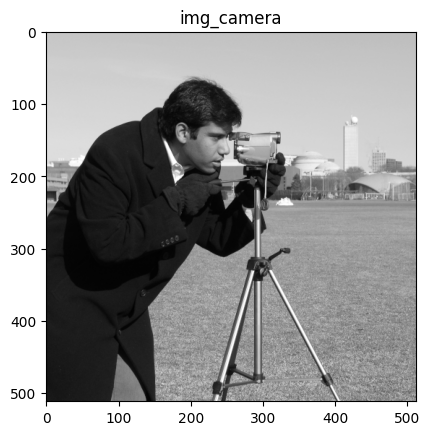

In [5]:
from skimage import data
import numpy as np
import matplotlib.pyplot as plt

img_camera = data.camera()

plt.figure()
plt.title("img_camera")
plt.imshow(img_camera, cmap="grey")

We will define a function to aply to each pixel, making the dark values, darker, the bright brighter and leaving a bigger range for de midtones.
Start with a simple umbral

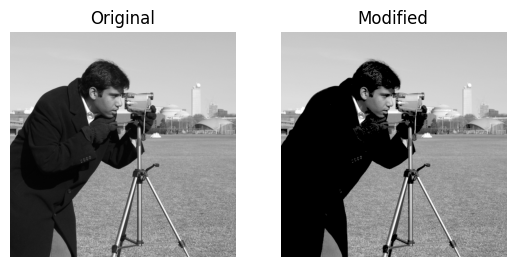

In [44]:
r1 = 50
r2 = 240
def basic_contrast(pixel):
    if pixel < r1:
        return 0
    elif pixel >= r2:
        return 255
    else:
        return pixel

# 2. La conviertes en una función vectorizada de NumPy
aply_contrast = np.vectorize(basic_contrast, otypes=[float]) 

# 3. Se la aplicas a la imagen completa
img_contrast = aply_contrast(img_camera)

img_contrast = np.clip(img_contrast, 0, 255).astype(np.uint8)

fig, ax = plt.subplots(1,2)
ax[0].axis("off")
ax[0].set_title("Original")
ax[0].imshow(img_camera, cmap='grey')

ax[1].axis("off")
ax[1].set_title("Modified")
ax[1].imshow(img_contrast, cmap='grey')

[[201 201 201 ... 186 187 187]
 [201 199 199 ... 187 187 187]
 [199 199 199 ... 187 187 187]
 ...
 [ 12  12  13 ... 119  96 130]
 [ 12  12  13 ... 144 122 158]
 [ 12  12  13 ... 135 136 132]]


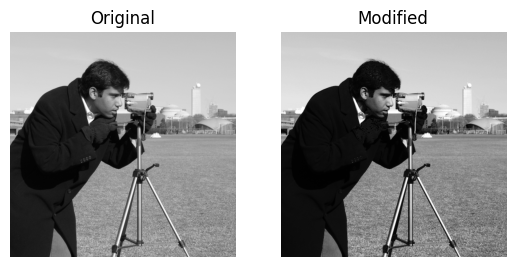

In [45]:
r1 = 50
r2 = 240
def contrast(pixel):
    if pixel < r1:
        return pixel / 2
    elif pixel >= r2:
        return pixel * 2
    else:
        return (pixel - r1) / (r2-r1) * 255
    
aply_contrast = np.vectorize(contrast, otypes=[float]) 

img_contrast_2 = aply_contrast(img_camera)

img_contrast_2 = np.clip(img_contrast_2, 0, 255).astype(np.uint8)
print(img_contrast_2)
fig, ax = plt.subplots(1,2)
ax[0].axis("off")
ax[0].set_title("Original")
ax[0].imshow(img_camera, cmap='grey')

ax[1].axis("off")
ax[1].set_title("Modified")
ax[1].imshow(img_contrast_2, cmap='grey')


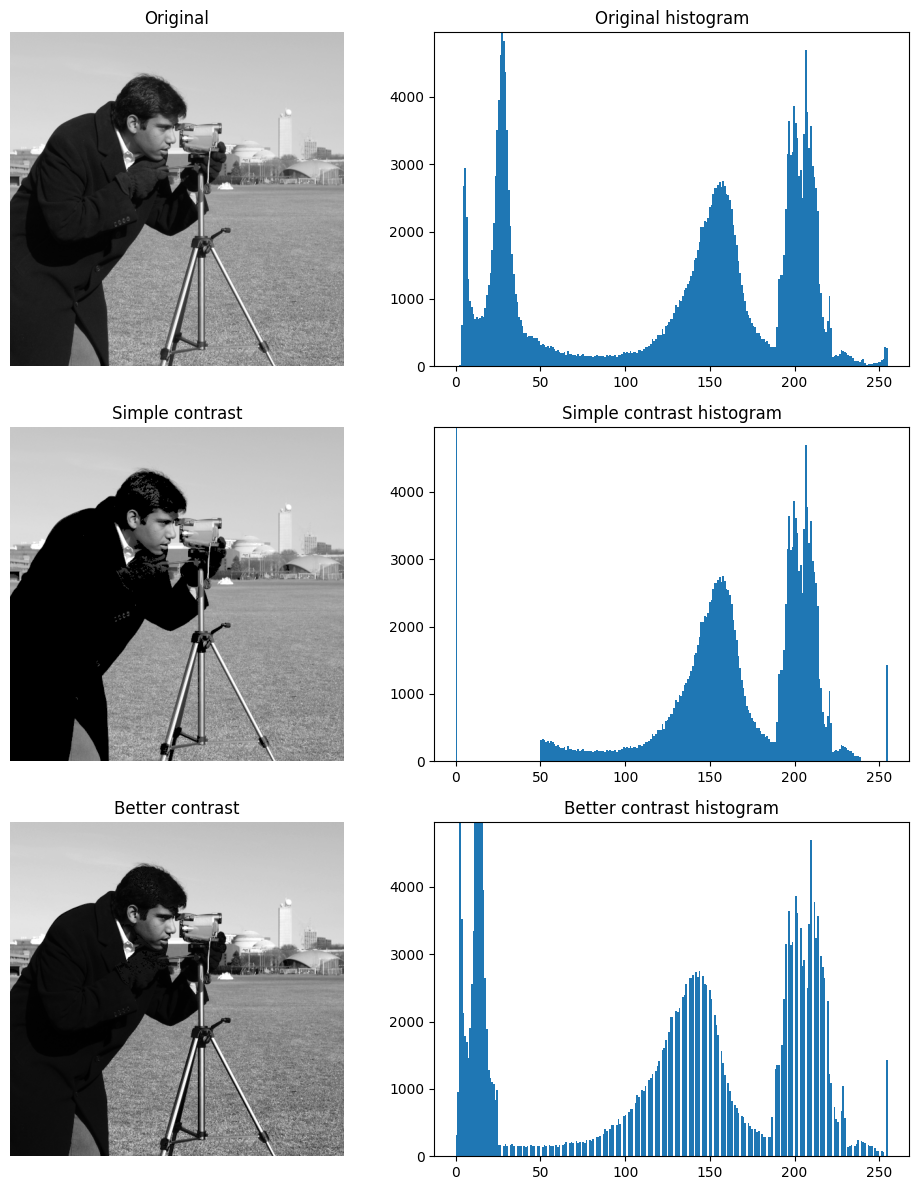

In [46]:
fig, ax = plt.subplots(3, 2, figsize=(10, 12))

# Original
ax[0][0].axis("off")
ax[0][0].set_title("Original")
ax[0][0].imshow(img_camera, cmap='gray')

ax[0][1].set_title("Original histogram")
ax[0][1].hist(np.ravel(img_camera), bins=256)

# Simple contrast
ax[1][0].axis("off")
ax[1][0].set_title("Simple contrast")
ax[1][0].imshow(img_contrast, cmap='gray')

ax[1][1].set_title("Simple contrast histogram")
ax[1][1].hist(np.ravel(img_contrast), bins=256)

#Better contrast
ax[2][0].axis("off")
ax[2][0].set_title("Better contrast")
ax[2][0].imshow(img_contrast_2, cmap='gray')

ax[2][1].set_title("Better contrast histogram")
ax[2][1].hist(np.ravel(img_contrast_2), bins=256)

# Limit Y: to have a visual clue on what change, but will cut some values on the simple histogram
count, _ = np.histogram(img_camera, bins=256)
max_y = np.max(count)
ax[0][1].set_ylim([0, max_y])
ax[1][1].set_ylim([0, max_y])
ax[2][1].set_ylim([0, max_y])

plt.tight_layout()
plt.show()
